#  Assignment 2
#### Niall Calvert
#### Group 17: I love STAT301
#### Group members: Oliver Hsueh, Karen Li, BRYAN Liao


In [1]:
install.packages("naniar")
library(ggplot2)
library(glmnet)
library(dplyr)
library(naniar)
library(caret)


set.seed(123)

hotel_bookings <- read.csv(
  "https://vincentarelbundock.github.io/Rdatasets/csv/bayesrules/hotel_bookings.csv"
)

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Loading required package: Matrix

Loaded glmnet 4.1-8


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: lattice



## 1) Data Description
The dataset provided is a hotel booking dataset that includes key information on the characteristics of the guests that booked the booking, and the type of booking that was made as well as the date and time and other miscellaneous information. 

In [2]:
numrows <- nrow(hotel_bookings)
numcols <- ncol(hotel_bookings)

numrows
numcols

[1] 1000

[1] 33

(The data includes 32 variables with an extra column called "rownames" which just enumerates each example.)

- **hotel**: `"Resort Hotel"` or `"City Hotel"`
- **is_canceled**: whether the booking was cancelled
- **lead_time**: number of days between booking and arrival
- **arrival_date_year**: year of scheduled arrival
- **arrival_date_month**: month of scheduled arrival
- **arrival_date_week_number**: week of scheduled arrival
- **arrival_date_day_of_month**: day of month of scheduled arrival
- **stays_in_weekend_nights**: number of reserved weekend nights
- **stays_in_week_nights**: number of reserved week nights
- **adults**: number of adults in booking
- **children**: number of children
- **babies**: number of babies
- **meal**: whether the booking includes breakfast (`BB = bed & breakfast`), breakfast and dinner (`HB = half board`), or breakfast, lunch, and dinner (`FB = full board`)
- **country**: guests country of origin
- **market_segment**: market segment designation (`e.g., TA = travel agent, TO = tour operator`)
- **distribution_channel**: booking distribution channel (`e.g., TA = travel agent, TO = tour operator`)
- **is_repeated_guest**: whether or not booking was made by a repeated guest
- **previous_cancellations**: guests number of previous booking cancellations
- **previous_bookings_not_canceled**: guests number of previous bookings that werent cancelled
- **reserved_room_type**: code for type of room reserved by guest
- **assigned_room_type**: code for type of room assigned by hotel
- **booking_changes**: number of changes made to the booking
- **deposit_type**: `No Deposit`, `Non Refund`, `Refundable`
- **agent**: booking travel agency
- **company**: booking company
- **days_in_waiting_list**: number of days the guest waited for booking confirmation
- **customer_type**: `Contract`, `Group`, `Transient`, `Transient-Party` (a transient booking tied to another transient booking)
- **average_daily_rate**: avera
- ge hotel cost per day
- **required_car_parking_spaces**: number of parking spaces the guest needed
- **total_of_special_requests**: number of guest special requests
- **reservation_status**: `Canceled`, `Check-Out`, `No-Show`
- **reservation_status_date**: when the guest cancelled or checked out

### Types of Variables #

In [3]:
hotel_type <- data.frame(
  variable = names(hotel_bookings),
  type = c(
    class(hotel_bookings$rownames),
    class(hotel_bookings$hotel),
    class(hotel_bookings$is_canceled),
    class(hotel_bookings$lead_time),
    class(hotel_bookings$arrival_date_year),
    class(hotel_bookings$arrival_date_month),
    class(hotel_bookings$arrival_date_week_number),
    class(hotel_bookings$arrival_date_day_of_month),
    class(hotel_bookings$stays_in_weekend_nights),
    class(hotel_bookings$stays_in_week_nights),
    class(hotel_bookings$adults),
    class(hotel_bookings$children),
    class(hotel_bookings$babies),
    class(hotel_bookings$meal),
    class(hotel_bookings$country),
    class(hotel_bookings$market_segment),
    class(hotel_bookings$distribution_channel),
    class(hotel_bookings$is_repeated_guest),
    class(hotel_bookings$previous_cancellations),
    class(hotel_bookings$previous_bookings_not_canceled),
    class(hotel_bookings$reserved_room_type),
    class(hotel_bookings$assigned_room_type),
    class(hotel_bookings$booking_changes),
    class(hotel_bookings$deposit_type),
    class(hotel_bookings$agent),
    class(hotel_bookings$company),
    class(hotel_bookings$days_in_waiting_list),
    class(hotel_bookings$customer_type),
    class(hotel_bookings$average_daily_rate),
    class(hotel_bookings$required_car_parking_spaces),
    class(hotel_bookings$total_of_special_requests),
    class(hotel_bookings$reservation_status),
    class(hotel_bookings$reservation_status_date)
  )
)
head(hotel_type)


,variable,type
,<chr>,<chr>
1,rownames,integer
2,hotel,character
3,is_canceled,integer
4,lead_time,integer
5,arrival_date_year,integer
6,arrival_date_month,character


### Authors description and Source

Authors description: A random subset of the data on hotel bookings originally collected by Antonio, 
Almeida and Nunes (2019) and distributed through the R for Data Science TidyTuesday project.

Source: 

Nuno Antonio, Ana de Almeida, and Luis Nunes (2019). "Hotel booking demand datasets." Data in Brief (22): 41-49. 
https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/hotels.csv/.

## Question

What are factors that are associated with whether a booking is cancelled or not? 

This question focuses on an inference, trying to find whether the added variables significantly improve the model. The response variable would be is_cancelled, and the linear regression model would model the response as the log odds that is_cancelled = 1, since we would be running a logistic regression since is_canceled is a binary variable. 


The most relevant variables I believe would be lead_time, deposit_type, customer_type, previous_cancellations, and market_segment. Although the dataset contains many variables, only a few relevant ones would be most relevant to the analysis. These variables are associated with the behaviour of the guest booking or cancelling their reservation. 

Other variables could be included as control variables. For example, adults, children, babies, arrival date, hotel could reduce confounding variables and improve the model fit. 


## Exploratory Data Analysis

variable,n_miss,pct_miss
<chr>,<int>,<num>
rownames,0,0
hotel,0,0
is_canceled,0,0
lead_time,0,0
arrival_date_year,0,0
arrival_date_month,0,0
arrival_date_week_number,0,0
arrival_date_day_of_month,0,0
stays_in_weekend_nights,0,0


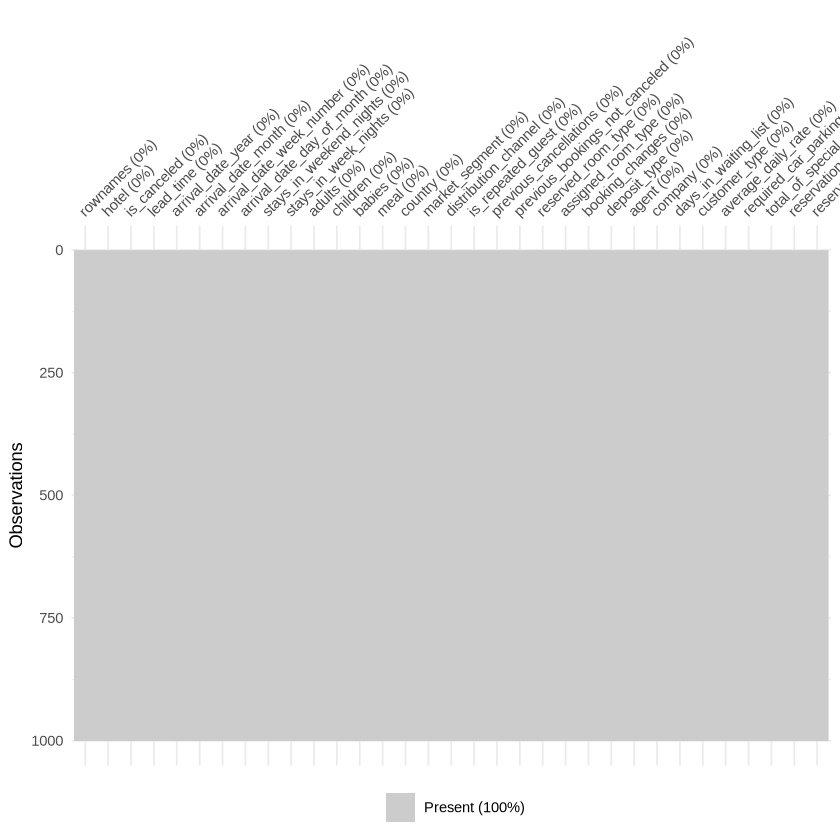

In [4]:
vis_miss(hotel_bookings)

miss_var_summary(hotel_bookings)

In [1]:
duplicated(hotel_bookings)
names(hotel_bookings)
# summary(hotel_bookings) 

ERROR: Error in eval(expr, envir, enclos): object 'hotel_bookings' not found


All the variable names are valid and none of the data are duplicated. Since none of the variables have NA's reported, there are no missing data points and there are no variables with a large proportion of missing data. From a quick check of the data, I saw that "hotel", "meal", "market_segment", and "deposit_type" had quite a high number of one variable in their categories. I shall thus clean the data accordingly: 

In [6]:
hotel_bookings$rownames <- NULL
hotel_bookings$hotel <- as.factor(hotel_bookings$hotel)
hotel_bookings$arrival_date_month <- as.factor(hotel_bookings$arrival_date_month)
hotel_bookings$meal <- as.factor(hotel_bookings$meal)
hotel_bookings$country <- as.factor(hotel_bookings$country)
hotel_bookings$market_segment <- as.factor(hotel_bookings$market_segment)
hotel_bookings$distribution_channel <- as.factor(hotel_bookings$distribution_channel)
hotel_bookings$reserved_room_type <- as.factor(hotel_bookings$reserved_room_type)
hotel_bookings$assigned_room_type <- as.factor(hotel_bookings$assigned_room_type)
hotel_bookings$deposit_type <- as.factor(hotel_bookings$deposit_type)
hotel_bookings$agent <- as.factor(hotel_bookings$agent)
hotel_bookings$company <- as.factor(hotel_bookings$company)
hotel_bookings$customer_type <- as.factor(hotel_bookings$customer_type)

hotel_bookings$reservation_status <- NULL
hotel_bookings$reservation_status_date <- NULL

In [7]:
categorical_vars <- c("hotel", "meal", "market_segment", "deposit_type")

hotel_counts <- table(hotel_bookings$hotel)
hotel_pct <- max(prop.table(hotel_counts))

meal_counts <- table(hotel_bookings$meal)
meal_pct <- max(prop.table(meal_counts))

market_segment_counts <- table(hotel_bookings$market_segment)
market_segment_pct <- max(prop.table(market_segment_counts))

deposit_type_counts <- table(hotel_bookings$deposit_type)
deposit_type_pct <- max(prop.table(deposit_type_counts))

imbalance_summary <- data.frame(
  variable = categorical_vars,
  max_pct = c(hotel_pct, meal_pct, market_segment_pct, deposit_type_pct)
)

imbalance_summary$max_pct <- round(imbalance_summary$max_pct * 100, 2)
imbalance_summary

variable,max_pct
<chr>,<dbl>
hotel,64.2
meal,76.1
market_segment,48.1
deposit_type,88.1


Therefore, these are the variables with the highest percentage of data dominated by one variable.

## Visualization

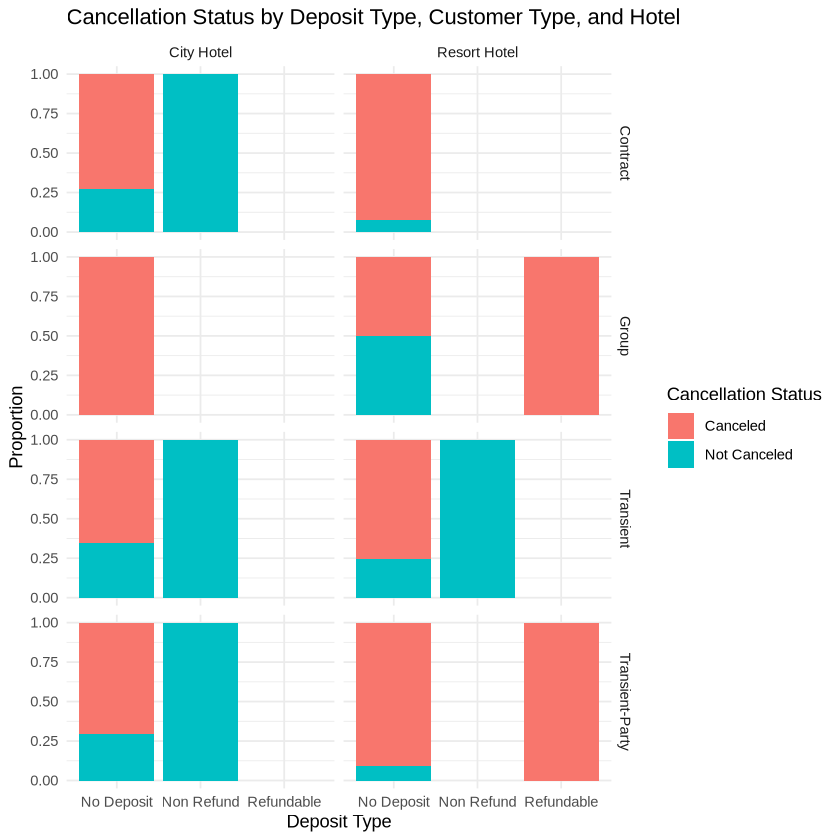

In [8]:
ggplot(hotel_bookings, aes(x = deposit_type, fill = factor(is_canceled))) +
  geom_bar(position = "fill") +
  facet_grid(customer_type ~ hotel) +
  labs(
    title = "Cancellation Status by Deposit Type, Customer Type, and Hotel",
    x = "Deposit Type",
    y = "Proportion",
    fill = "Cancellation Status"
  ) +
  scale_fill_discrete(labels = c("Canceled", "Not Canceled")) +
  theme_minimal()

This plot is relevant because it combines four variables that track a guests behaviour booking their room. This includes customer type, cancellation status, hotel type and deposit type. Through our question, we want to explore what variables explain a room being cancelled. This plot also shows that there may be a role between deposit status and whether a booking is cancelled, which may help with variable selection in the next phase of the project. It also lets us explore whether the type of customer affects how the cancellation status. 

## Usage of AI tools

I used ChatGPT to help debug the code. 

#### Response to Assignment 1 feedback

I have implemented the naniar package and included a summary of the missing variables of the dataset.

### Methods and plan

a) I will use the question I proposed in my first assignment, what are factors that are associated with whether a booking is cancelled or not? 

b) To answer this question, I will run a hypothesis test on a subset of variables chosen using Lasso. I will split the data into a training set and a testing set. Next, using the variables chosen from the training stage, I will run a hypothesis test on the testing data to address the post inference problem. I will use an additive linear model that uses the log odds of the is_cancelled variable as the response since it is a binary variable. Through this hypothesis test, I will be able to identify the variables most associated with whether a booking is cancelled. I need to split the data into a subset of variables because including all the variables would cause trouble with interpretation. Lasso selects variables in the data that are the most relevant. 

c) Some important assumptions for Lasso would be that there is a linear relationship between the data, all observations are independent, only some variables are truly important (data is sparse), and there is limited multicollinearity. In fact I removed reservation_status and reservation_status_date because they are very collinear with the response, is_cancelled. These two variables are reported after a booking outcome happens. reservation_status == "cancelled" essentially duplicates is_cancelled and reservation_status_date is only recorded after a booking is cancelled, leading to inherent bias. is_cancelled also must have binary output, since we are using logistic regression.

Lasso does not work well when many variables are important (ie it works well only when there are a small subset of variables). Lasso also chooses dummy variables, so interpreting the variables chosen using lasso may be awkward with a lot of categorical variables. We also cannot use the Lasso estimates for hypothesis testing since they are biased, so we have to refit a new model with the variables selected using Lasso to conduct a hypothesis test. 


#### Training the data and building the model matrix

In [9]:
n <- nrow(hotel_bookings)



train_idx <- createDataPartition(hotel_bookings$is_canceled, p = 0.8, list = FALSE)

train_data <- hotel_bookings[train_idx, ]
test_data  <- hotel_bookings[-train_idx, ]


x_train <- model.matrix(is_canceled ~ ., data = train_data)[, -1]
x_test  <- model.matrix(is_canceled ~ ., data = test_data)[, -1]

y_train <- train_data$is_canceled
y_test  <- test_data$is_canceled

#### Fitting Lasso

In [10]:
cv_lasso <- cv.glmnet(
  x = x_train,
  y = y_train,
  family = "binomial",
  alpha = 1,
  nfolds = 5
)

#### Output

In [11]:
mm_train <- model.matrix(is_canceled ~ ., data = train_data)
term_labels <- attr(terms(is_canceled ~ ., data = train_data), "term.labels")
assign_vec <- attr(mm_train, "assign")[-1]

lasso_coef <- coef(cv_lasso, s = "lambda.1se")

selected_idx <- as.vector(lasso_coef[-1, 1] != 0)
selected_terms <- unique(term_labels[assign_vec[selected_idx]])

selected_coefficients <- rownames(lasso_coef)[lasso_coef[, 1] != 0]

cat("\nOriginal variables selected by LASSO:\n")
print(selected_terms)

cat("\nNumber of original variables selected:", length(selected_terms), "\n")

num_selected <- sum(lasso_coef[-1, ] != 0)
cat("Number of variables selected (including dummy variables):", num_selected, "\n")


Original variables selected by LASSO:
 [1] "lead_time"                   "arrival_date_year"          
 [3] "stays_in_weekend_nights"     "adults"                     
 [5] "children"                    "babies"                     
 [7] "country"                     "market_segment"             
 [9] "reserved_room_type"          "assigned_room_type"         
[11] "booking_changes"             "deposit_type"               
[13] "agent"                       "company"                    
[15] "customer_type"               "average_daily_rate"         
[17] "required_car_parking_spaces" "total_of_special_requests"  

Number of original variables selected: 18 
Number of variables selected (including dummy variables): 37 


#### Running the hypothesis test

In [12]:
selected_vars <- selected_coefficients[selected_coefficients != "(Intercept)"]

df <- data.frame(
  is_canceled = y_test,
  x_test[, selected_vars, drop = FALSE]
)

logit_model <- glm(is_canceled ~ ., data = df, family = binomial)

summary(logit_model)

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = is_canceled ~ ., family = binomial, data = df)

Coefficients: (12 not defined because of singularities)
                              Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 -4.515e+02  7.845e+02  -0.576  0.56493    
lead_time                    8.739e-03  2.948e-03   2.964  0.00303 ** 
arrival_date_year            2.219e-01  3.891e-01   0.570  0.56847    
stays_in_weekend_nights      2.490e-01  2.397e-01   1.039  0.29896    
adults                      -1.590e-01  4.849e-01  -0.328  0.74303    
children                     5.901e-01  5.817e-01   1.014  0.31040    
babies                       3.567e+00  1.302e+04   0.000  0.99978    
countryDNK                          NA         NA      NA       NA    
countryFRA                   6.421e-01  7.961e-01   0.807  0.41992    
countryIRL                   7.968e-02  1.458e+00   0.055  0.95641    
countryLUX                          NA         NA      NA       NA    
countryPRT             

## Visualization

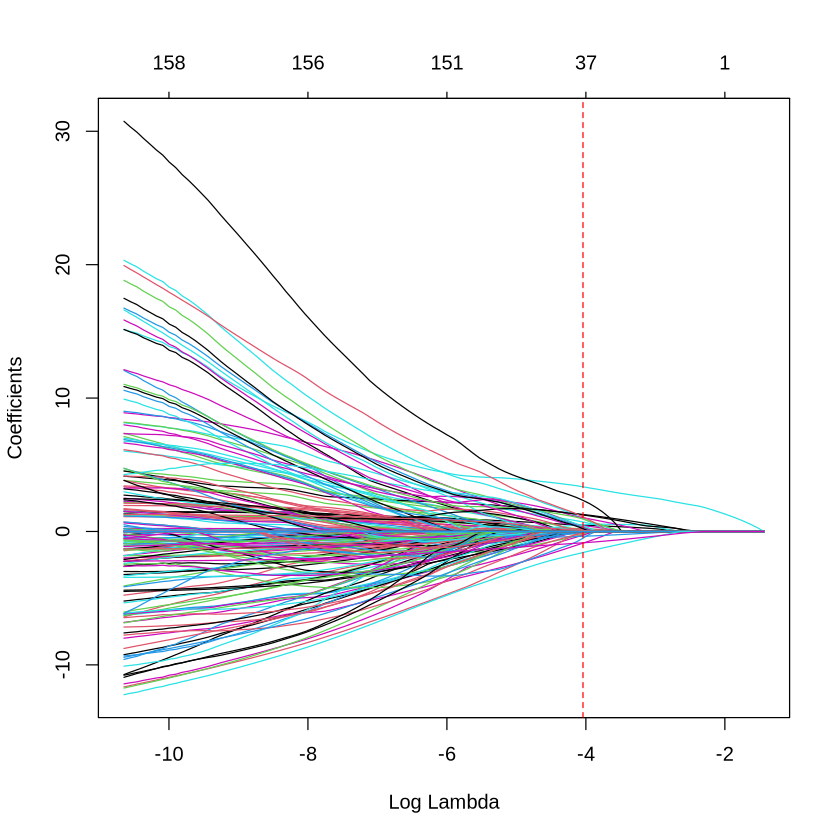

In [13]:
plot(cv_lasso$glmnet.fit, xvar = "lambda")
abline(v = log(cv_lasso$lambda.1se), col = "red", lty = 2)

#### Interpretation
From the summary table, the results show that several variables, including lead time, country, booking changes, average daily rate, and total special requests are significantly associated with whether a booking is cancelled or not. However, many variables have extremely large standard errors or are not estimated at all, which may imply that there are issues with sparse categories, multicollinearity, and perfect separation. This suggests that there is potential for improvement in the model, for example by collapsing rare categories or by using group LASSO, since there are many categorical variables in the dataset.